Outside of the notes I take on the slides, I will use the markdown notes and code notes for what is necessary and for the activites. For the most part tho I am using these to write down some of the activities and to follow along with the live coding. Actual notes I ususally take by hand as that is how I prefer to notetake. 

ACTIVITY: Life expentancy graph. (Plus the others I did not see coming below)

The graph is rather ugly, the 3d plot makes it hard to read, the style is unclear and the accuracy of the scales and graph as a whole is off.

The monstrous cost one is worse in my opinion, although a cool visual, impossible to read the data, the scale is angled and makes everything warped, and the data looks stranged. 

Same data presented with different aspect ratios. The issue is that depending on the ratio the message changes. One change looks a lot steeper and intense than the wide graph.

Next one looks at the 2012 presidential election. One the summation does not make sense as it goes beyond 100%, once again it is 3d for some reason, the colours don't really make sense either. ALso the source being just opinions is strange.

Last visualization is the wind plot. Some minor issues with the lower speeds, and with the speeds not being linear, however, overall a good visualization of a dynamic system.

See all the available tools to make data visualization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [3]:
# Set seed for reproducibility, then generate sample data
np.random.seed(613)
x = np.arange(50)
y = np.random.randint(0, 100, 50)

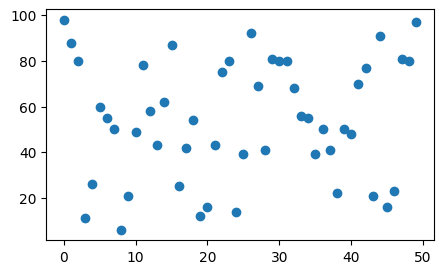

In [4]:
# Using Matplotlib we can make a basic scatter plot
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(x, y)
plt.show()

<BarContainer object of 50 artists>

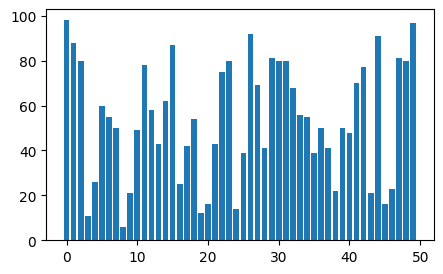

In [8]:
# Bar chart — same data, just swap ax.scatter for ax.bar. Replicated from above. 
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(x, y)


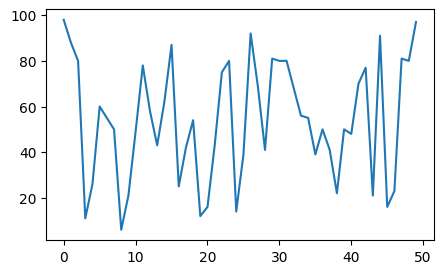

In [7]:
# Line plot, again same data, just swap ax.scatter for ax.plot. Replicated from above.
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y)


 Histogram

**Activity answer:** A histogram uses `ax.hist()`. Note that unlike scatter/bar/line, `hist` only takes `y` (it bins the values automatically — no need to pass `x`).

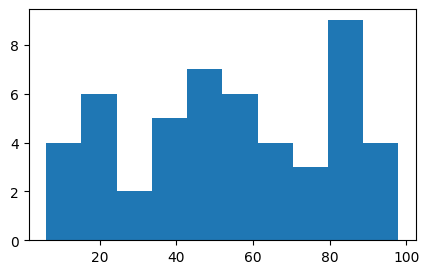

In [9]:
# Histogram — ax.hist only needs y (it computes the bins itself)
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(y)
plt.show()

Adding labels:

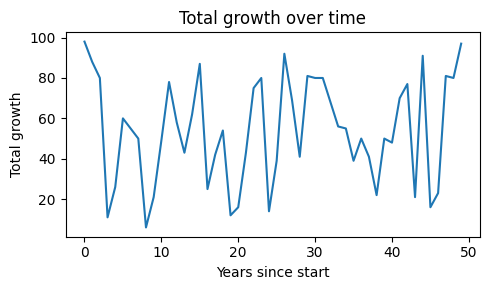

In [10]:
# Add axis labels and a title to the line plot
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y)
ax.set_title('Total growth over time')
ax.set_ylabel('Total growth')
ax.set_xlabel('Years since start')
fig.tight_layout()
plt.show()

Modifying the labels. 
A `fontdict` is just a plain Python dictionary with font properties.
You can pass it to `set_title`, `set_xlabel`, and `set_ylabel` to control font family, colour, and size.

In [11]:
# Define two font styles as dictionaries
font1 = {'family': 'sans-serif', 'color': 'blue', 'size': 20}   # for the title
font2 = {'family': 'monospace', 'color': 'green', 'size': 14}   # for axis labels

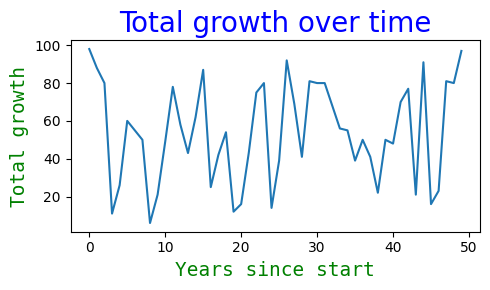

In [12]:
# Apply the font dictionaries to our line plot
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y)
ax.set_title('Total growth over time', fontdict=font1)
ax.set_ylabel('Total growth', fontdict=font2)
ax.set_xlabel('Years since start', fontdict=font2)
fig.tight_layout()
plt.show()

## Moving Labels with loc

The loc argument on set_xlabel / set_ylabel lets you align labels: left, center' (default), or right for x; bottom', center', or 'top' for y.

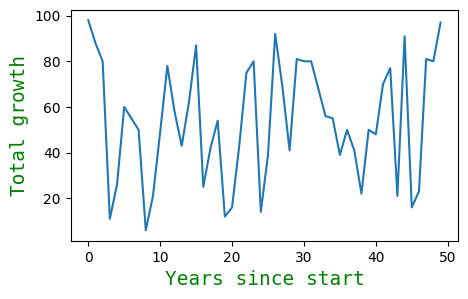

In [13]:
# Demonstrating label positioning with loc
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y)
ax.set_ylabel('Total growth', fontdict=font2)       # try loc='top' or 'bottom'
ax.set_xlabel('Years since start', fontdict=font2)  # try loc='left' or 'right'
plt.show()

Customizing Plot appearance. 

/var/folders/7h/6rwj6_9s07385qm58bt7brx80000gn/T/ipykernel_10592/4221738883.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


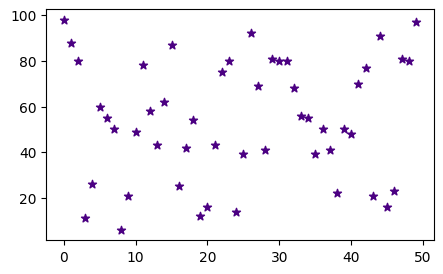

In [14]:
# Scatter plot with custom marker and named colour
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(x,
           y,
           marker='*',       # star-shaped markers
           color='indigo')   # named matplotlib colour
fig.show()

/var/folders/7h/6rwj6_9s07385qm58bt7brx80000gn/T/ipykernel_10592/1445993460.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


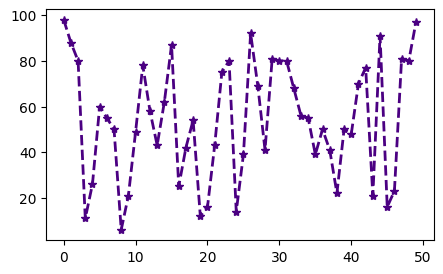

In [15]:
# Line plot with custom marker, colour, linestyle, and linewidth
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,
        y,
        marker='*',
        color='indigo',
        linestyle='--',   # dashed line; try '-', ':', '-.'
        linewidth=2)      # line thickness in points
fig.show()

Using Hex codes for colouring the plots.

/var/folders/7h/6rwj6_9s07385qm58bt7brx80000gn/T/ipykernel_10592/2654508719.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


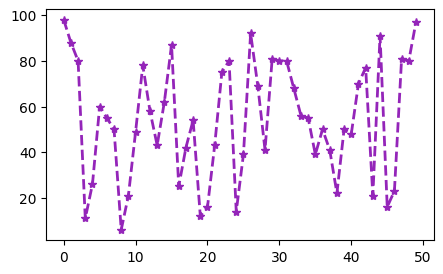

In [20]:
# Same plot, but using a hex colour code instead of a named colour
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y, marker='*', color='#9425b9', linestyle='--', linewidth=2) #i played with the hex code for a bit (by changing the first digit only)
fig.show()

Marker edge and face colours

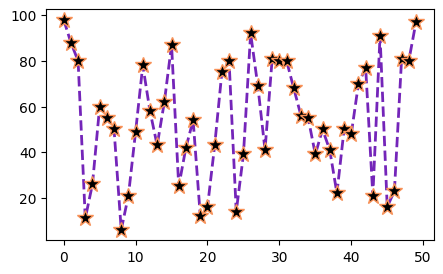

In [21]:
# Fully customized line plot with two-tone markers
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y,
        marker='*',
        markersize=12,                  # marker size in points
        color='#7425b9',
        linestyle='--',
        linewidth=2,
        markeredgecolor='#fa9359',      # orange outline
        markerfacecolor='#000000')      # black fill
plt.show()

Grid Lines

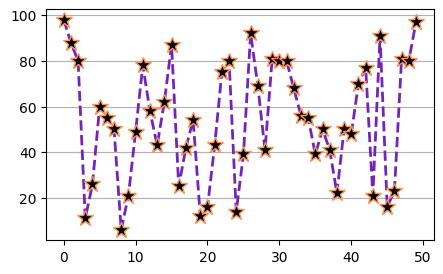

In [22]:
# Basic horizontal grid lines
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y, marker='*', markersize=12, color='#7425b9',
        linestyle='--', linewidth=2,
        markeredgecolor='#fa9359', markerfacecolor='#000000')
ax.grid(axis='y')
plt.show()

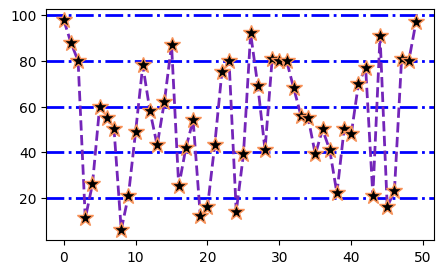

In [23]:
# Styled grid lines — colour, width, and linestyle work just like on a plot line
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y, marker='*', markersize=12, color='#7425b9',
        linestyle='--', linewidth=2,
        markeredgecolor='#fa9359', markerfacecolor='#000000')
ax.grid(axis='y', color='blue', linewidth=2, linestyle='-.')
plt.show()

Activity: Exploring matplotlib and the Python gallery. Note we didn't actually go over this activity, at least during this session, but I decided to play around with some graphs anyways and do the reflection (also played around with markdown a bit more)

**Chart chosen:** [#34 — Grouped Boxplot](https://python-graph-gallery.com/34-grouped-boxplot/) from the Python Graph Gallery.

A **grouped boxplot** (also called a multi-level boxplot) displays the distribution of a numeric variable split across two categorical variables at once:
- The **x-axis** groups by one category (e.g., day of the week)
- The **hue** (colour) groups by a second category within each x group (e.g., lunch vs. dinner)

We use the built-in tips dataset from seaborn — a classic dataset recording restaurant tip amounts, with columns for total bill, tip, sex, smoker status, day, meal time, and party size.

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the built-in tips dataset
# Contains: total_bill, tip, sex, smoker, day, time, size
df = sns.load_dataset('tips')

# Quick look at the data
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


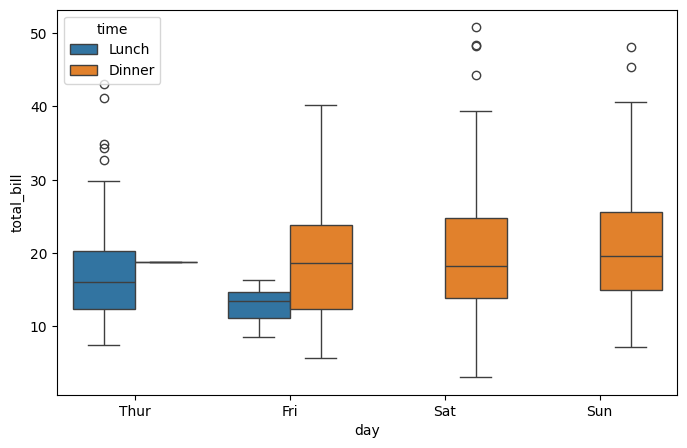

In [26]:
# Basic grouped boxplot: total_bill by day, split by time (Lunch vs Dinner)
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='day',          # primary group: day of the week
    y='total_bill',   # numeric variable: restaurant bill amount
    hue='time',       # secondary group: Lunch or Dinner
    ax=ax             # pass our matplotlib axes object so we can customize further
)

plt.show()

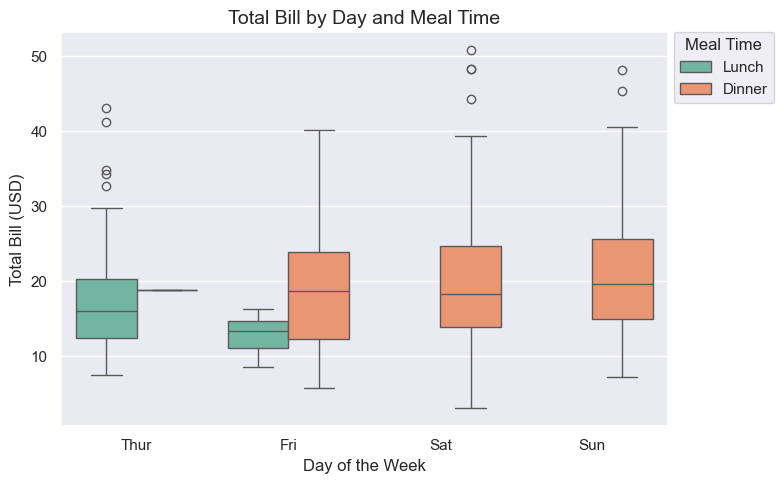

In [27]:
# Set a clean theme and play around with the above plot to make it nicer and more coherent to look at.
sns.set_theme(style='darkgrid')

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='day',
    y='total_bill',
    hue='time',
    palette='Set2',   # colourblind-friendly categorical palette
    ax=ax
)

# Labels and title — same matplotlib methods as earlier in the notebook
ax.set_title('Total Bill by Day and Meal Time', fontsize=14)
ax.set_xlabel('Day of the Week', fontsize=12)
ax.set_ylabel('Total Bill (USD)', fontsize=12)

# Move the legend outside the plot area so it doesn't overlap the boxes
ax.legend(title='Meal Time', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

fig.tight_layout()   # prevent the legend from being clipped
plt.show()

Reflection for the final activity. 

Recall the three qualities of a good data visualization, all below and addressed.

**Aesthetic quality:**
The darkgrid seaborn theme provides a clean, readable background. The Set2 palette uses muted, distinct colours that are easy on the eye and don't compete with the data. The legend is placed outside the plot to avoid overlap. Overall the chart is uncluttered and well-proportioned.

**Substantive quality:**
The chart faithfully represents the tips dataset, no data is hidden or distorted. The y-axis starts at 0 implicitly via the data range and is not truncated in a misleading way. The boxplot summary statistics (median, IQR, outliers) are standard and well-defined, so the encoding is accurate.

**Perceptual quality:**
Grouped boxplots do require some prior knowledge to read — a viewer unfamiliar with the box-and-whisker format may not immediately know what the box edges or whiskers mean. However, for a data-literate audience, the side-by-side layout makes the Lunch vs. Dinner comparison across days very easy to decode at a glance. The use of colour (hue) rather than position alone to encode the second grouping adds redundancy that aids perception.